# 06-Streaming：让执行过程“可见”

stream_mode · stream_events(version="v3") · values/updates · 第六课 · 约 40 分钟

### 目录

-   回顾：图能选路、能存档、能暂停恢复了
-   一、为什么必须“可见”？（否则就是黑盒）
-   二、两条路：stream_mode（经典） vs stream_events v3（更像应用层）
-   补充：为什么你会觉得 stream 和 stream_events 很像？（对照实验）
-   三、用 updates 看“每个节点到底返回了什么”
-   四、用 values 看“每一步 state 合并后长什么样”
-   五、stream_events(version="v3")：values/output/interrupted/interrupts
-   六、把 streaming 用在 HIL：UI 怎么显示“等待审批”？
-   七、常见坑速查
-   八、总结

### 回顾：图能跑，但你看不见它怎么跑

前面几课我们已经让图具备了三项“产品级能力”：

- 图会自己选路（条件路由）
- 图会记住状态（Checkpointer + thread_id）
- 图能停下来等人（interrupt + resume）

但还有个痛点：**它跑起来像黑盒**。

这节课要解决的就是：让你能在 Jupyter 里亲眼看到“每一步发生了什么”。


### 一、为什么必须“可见”？（否则就是黑盒）

想象你做了一个退款流程：

- 你以为已经把金额从 500 改成 300
- 你以为图已经走到了“执行退款”

但最后打印出来还是 500。

如果没有 streaming，你只能猜：

- 到底执行了哪个节点？
- 每个节点返回了什么 update？
- 合并后的 state 在每一步长什么样？

> **类比：物流信息**
>
> - 没有物流：你只知道“下单了”和“签收了”，中间全靠猜。
> - 有物流：你能看到每一个状态（已揽收、运输中、派送中…）。
>
> Streaming 就是 LangGraph 的“物流信息”。

### 二、两条路：stream_mode vs stream_events v3

先记一句话：

- `graph.stream(..., stream_mode=...)`：更像“底层调试视角”（增量 update / 合并快照）。
- `graph.stream_events(..., version="v3")`：更像“应用层视角”（values/output/interrupted/interrupts 等投影）。

这节课我们两种都学：先用 `stream_mode` 建立直觉，再用 v3 把它接到 UI/HIL 的常见用法上。

> **官方口径（很容易让人困惑）**
>
> - 官方文档会说：新应用推荐用 `stream_events(version="v3")`（typed projections，更像应用层）。
> - 但在 API 参考里，v3 仍可能带有 “experimental/beta” 的提示。
>
> 所以本教程的态度很简单：**学习 v3 的用法（因为它更贴 UI/HIL），但生产要锁版本**，避免未来升级带来的细微变更。


In [1]:
import operator
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END


class RefundState(TypedDict):
    order: str
    amount: int
    logs: Annotated[list[str], operator.add]
    result: str


def prepare(state: RefundState):
    return {"logs": [f"[prepare] order={state['order']} amount={state['amount']}"]}


def apply_policy(state: RefundState):
    # 规则示意：金额 > 1000 需要走特殊流程；这里我们只记一条 log
    need_extra = state["amount"] > 1000
    return {"logs": [f"[apply_policy] need_extra={need_extra}"]}


def finalize(state: RefundState):
    return {
        "logs": ["[finalize] done"],
        "result": f"已退款 {state['amount']} 元",
    }


builder = StateGraph(RefundState)
builder.add_node("准备", prepare)
builder.add_node("规则", apply_policy)
builder.add_node("执行", finalize)
builder.add_edge(START, "准备")
builder.add_edge("准备", "规则")
builder.add_edge("规则", "执行")
builder.add_edge("执行", END)

graph_refund = builder.compile()

init_state: RefundState = {
    "order": "A1001",
    "amount": 500,
    "logs": [],
    "result": "",
}

print("=== init_state ===")
print(init_state)

=== init_state ===
{'order': 'A1001', 'amount': 500, 'logs': [], 'result': ''}


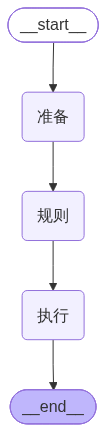

In [3]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph_refund.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

### 补充：为什么你会觉得 stream 和 stream_events 很像？

你的感觉非常正常。

在本章里，我们对 `stream_events(version="v3")` 只用了最像 `stream_mode="values"` 的那一面：

- `stream.values`：一帧一帧的 state 快照
- `stream.output`：最终 state

所以观感会很接近。

真正的差异，通常要在“**同一次运行我想同时拿两类信息**”时才会立刻显出来：

- `stream_mode=["updates", "values"]` 会把不同类型的 chunk **混在同一条流里吐出来**（你要自己分流处理）。
- `stream_events(version="v3")` 则把结果拆成多个“投影/频道”（`stream.values / stream.output / stream.interrupts ...`），你直接读对应频道就行。

下面我们做一个 10 行的对照实验。


In [ ]:
print("=== stream_mode=['updates','values']（默认格式：tuple 混流）===")
for mode, chunk in graph_refund.stream(init_state, stream_mode=["updates", "values"]):
    print(mode, chunk)

print("\n=== stream_mode=['updates','values'] + version='v2'（统一格式：dict 混流）===")
for part in graph_refund.stream(init_state, stream_mode=["updates", "values"], version="v2"):
    print(part["type"], part["data"])

### 三、用 updates 看“每个节点到底返回了什么”

先回答你可能会顺带问的另一个问题：`invoke` 和 `stream` 功能一样吗？

- `invoke()`：执行整张图，**只返回最终 state**。
- `stream(..., stream_mode=...)`：执行整张图，**边跑边吐过程**。

所以它们“跑出来的最终结果”是一致的，但 `stream` 多了过程。

`updates` 会把每一步“哪个节点返回了什么 update”直接吐出来。

你应该看到：每个 chunk 是一个字典，key 是节点名，value 是该节点返回的增量 update。


In [4]:
print("=== stream_mode=updates ===")
for chunk in graph_refund.stream(init_state, stream_mode="updates"):
    print(chunk)

=== stream_mode=updates ===
{'准备': {'logs': ['[prepare] order=A1001 amount=500']}}
{'规则': {'logs': ['[apply_policy] need_extra=False']}}
{'执行': {'logs': ['[finalize] done'], 'result': '已退款 500 元'}}


### 四、用 values 看“每一步 state 合并后长什么样”

`values` 会把“合并后的 state 快照”一帧一帧吐出来。

你应该看到：

- `logs` 会越来越长（因为我们给 `logs` 配了 reducer：`operator.add`）
- 最后一帧会出现 `result`

> **❓ 检查理解 ①**
>
> 如果我们把 `logs: Annotated[list[str], operator.add]` 改成 `logs: list[str]`（不写 reducer），再跑一次 `stream_mode="values"`，你最可能看到什么？
>
> -   A. `logs` 仍然会越来越长
> -   B. `logs` 每一步都只保留最后一次写入（被覆盖）
> -   C. 会直接报错，无法运行
>
> **✅ 答案：B**
>
> 不写 reducer 时，默认合并策略是“覆盖”。所以 `logs` 不会累加，而是被每个节点的返回值覆盖。


In [5]:
print("=== stream_mode=values ===")
for i, snapshot in enumerate(graph_refund.stream(init_state, stream_mode="values")):
    print(f"-- step {i} --")
    print(snapshot)
    print()

=== stream_mode=values ===
-- step 0 --
{'order': 'A1001', 'amount': 500, 'logs': [], 'result': ''}

-- step 1 --
{'order': 'A1001', 'amount': 500, 'logs': ['[prepare] order=A1001 amount=500'], 'result': ''}

-- step 2 --
{'order': 'A1001', 'amount': 500, 'logs': ['[prepare] order=A1001 amount=500', '[apply_policy] need_extra=False'], 'result': ''}

-- step 3 --
{'order': 'A1001', 'amount': 500, 'logs': ['[prepare] order=A1001 amount=500', '[apply_policy] need_extra=False', '[finalize] done'], 'result': '已退款 500 元'}



### 五、stream_events(version="v3")：values/output

`stream_events(version="v3")` 返回的不是“事件字典列表”，而是一个 **run stream 句柄**。

你可以把它当成一个“多路输出的流”：

- `stream.values`：合并后的 state 快照
- `stream.output`：最终输出（驱动运行到完成或暂停）

> 这一节我们不接真实大模型，重点只看 state 与最终输出，保证离线可跑、输出稳定。

> **❓ 检查理解 ②**
>
> 你用 `stream_events(version="v3")` 驱动运行后，想拿到最终 state，应该读哪个字段？
>
> -   A. `stream.values` 的最后一个 snapshot
> -   B. `stream.output`
> -   C. `stream.interrupts`
>
> **✅ 答案：B**
>
> `stream.output` 是“最终输出/最终 state”的统一出口；`stream.values` 是过程快照；`stream.interrupts` 是 HIL 暂停时抛出的 payload。


In [6]:
stream = graph_refund.stream_events(init_state, version="v3")

print("=== stream_events v3: values ===")
for i, snapshot in enumerate(stream.values):
    print(f"-- step {i} --")
    print(snapshot)
    print()

final_state = stream.output
print("=== stream_events v3: output ===")
print(final_state)

=== stream_events v3: values ===
-- step 0 --
{'order': 'A1001', 'amount': 500, 'logs': [], 'result': ''}

-- step 1 --
{'order': 'A1001', 'amount': 500, 'logs': ['[prepare] order=A1001 amount=500'], 'result': ''}

-- step 2 --
{'order': 'A1001', 'amount': 500, 'logs': ['[prepare] order=A1001 amount=500', '[apply_policy] need_extra=False'], 'result': ''}

-- step 3 --
{'order': 'A1001', 'amount': 500, 'logs': ['[prepare] order=A1001 amount=500', '[apply_policy] need_extra=False', '[finalize] done'], 'result': '已退款 500 元'}

=== stream_events v3: output ===
{'order': 'A1001', 'amount': 500, 'logs': ['[prepare] order=A1001 amount=500', '[apply_policy] need_extra=False', '[finalize] done'], 'result': '已退款 500 元'}


/home/miao/anaconda3/envs/tp-rag/lib/python3.12/site-packages/langgraph/pregel/main.py:3723: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return self._pregel_stream_v3(
/home/miao/anaconda3/envs/tp-rag/lib/python3.12/site-packages/langgraph/pregel/main.py:3573: LangChainBetaWarning: The v3 streaming protocol on Pregel is experimental.
  return GraphRunStream(graph_iter, mux)


### 六、把 streaming 用在 HIL：UI 怎么显示“等待审批”？

当图里出现 `interrupt()` 时，运行会在某一步暂停。

如果你用 `stream_events(version="v3")` 驱动：

- `stream.interrupted` 会告诉你“是否暂停了”
- `stream.interrupts` 会给出 `interrupt(...)` 抛出来的 payload

这非常像前端要的东西：

- UI 收到 payload → 弹窗/工单/企业微信让人审批
- 人给出决定 → 再用 `Command(resume=...)` 继续跑


In [7]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command, interrupt


def human_gate(state: RefundState):
    decision = interrupt(
        {
            "question": "是否批准退款？",
            "order": state["order"],
            "amount": state["amount"],
        }
    )
    return {"logs": [f"[human_gate] decision={decision}"]}


def finalize_with_gate(state: RefundState):
    # 模式：人拒绝就不退，人通过才执行
    last = state["logs"][-1] if state["logs"] else ""
    if "decision=approve" in last:
        return {"result": f"已退款 {state['amount']} 元"}
    return {"result": "退款被拒绝"}


builder_hil = StateGraph(RefundState)
builder_hil.add_node("准备", prepare)
builder_hil.add_node("人工审批", human_gate)
builder_hil.add_node("执行", finalize_with_gate)
builder_hil.add_edge(START, "准备")
builder_hil.add_edge("准备", "人工审批")
builder_hil.add_edge("人工审批", "执行")
builder_hil.add_edge("执行", END)

graph_hil_stream = builder_hil.compile(checkpointer=InMemorySaver())
config_hil_stream = {"configurable": {"thread_id": "stream-hil-001"}}

# ① 第一次驱动：会在 interrupt 暂停
stream = graph_hil_stream.stream_events(init_state, config=config_hil_stream, version="v3")
final_or_pause = stream.output

print("interrupted:", stream.interrupted)
print("interrupts:", stream.interrupts)

# ② 恢复执行：把人的决定传回来
stream2 = graph_hil_stream.stream_events(
    Command(resume="approve"),
    config=config_hil_stream,
    version="v3",
)
final_state = stream2.output
print("final:", final_state["result"])

interrupted: True
interrupts: [Interrupt(value={'question': '是否批准退款？', 'order': 'A1001', 'amount': 500}, id='53cbc774a4395f11301f99c87a20c9d8')]
final: 已退款 500 元


### 七、常见坑速查

| 症状 | 原因 | 解法 |
| --- | --- | --- |
| values 看起来“不累加” | 没给列表字段配置 reducer（默认是覆盖） | 用 `Annotated[list[T], operator.add]` 或 `add_messages`（messages 场景） |
| updates 看不懂 | 你把“合并后的 state”当成了 update | 记住：updates 是“节点返回的增量”，values 才是“合并后的快照” |
| stream_events v3 里怎么没有 stream_mode | v3 是“投影式”API，不用 stream_mode | 用 `stream.values/stream.output/stream.interrupts` 等投影 |
| resume 不生效/报错 | 没挂 checkpointer，或 thread_id 不一致 | `compile(checkpointer=...)` + 恢复用同一个 thread_id |
| 期望看到 token 级别 messages 流，但这里没有 | 本章离线不接真实大模型 | 先把 state/控制流/interrupt 流跑透；需要 token 再接真实模型 |


### 八、总结

| 概念 | 一句话解释 | 你应该记住什么 |
| --- | --- | --- |
| invoke() | 一次性把图跑完，返回最终 state（或 `__interrupt__`） | 适合“只要结果”；过程是黑盒 |
| stream(stream_mode="updates") | 每一步吐出“节点返回的增量 update” | 看清楚每个节点到底写了哪些 key |
| stream(stream_mode="values") | 每一步吐出“合并后的 state 快照” | 看 reducer 合并后的最终样子（最直观） |
| stream(stream_mode=["updates","values"]) | 两种信息混在同一条流里，需要自己分流 | 默认格式是 `(mode, data)` tuple；想更好处理可用 `version="v2"` |
| version="v2"（stream） | 把混流统一成 dict 结构（`type/ns/data`） | 减少 tuple 拆包，便于工程代码处理多 mode/子图 |
| stream_events(version="v3") | 返回 run stream 句柄，按“投影/频道”消费 | 不用自己分流：`stream.values` / `stream.output` / `stream.interrupted` / `stream.interrupts` |
| HIL + streaming | 暂停时把 payload 抛给外部，恢复后继续 | UI 最关心的是：有没有暂停、暂停抛了什么、最终输出是什么 |

> **一句话总结**
>
> `invoke` 只给结果；`stream` 把过程“直播出来”。
>
> updates = 节点增量；values = 合并快照；多 mode = 混流要分拣；v2 让混流结构统一；v3 让输出分频道（投影）。

📖 参考：

- [LangGraph 官方文档 - Streaming](https://docs.langchain.com/oss/python/langgraph/streaming)
- [LangGraph 官方文档 - Event streaming](https://docs.langchain.com/oss/python/langgraph/event-streaming)
- [LangGraph 官方文档 - Interrupts](https://docs.langchain.com/oss/python/langgraph/interrupts)
